# Comparing different NLP Backends

We load an emotion classifier with six classes (sadness, joy, love, anger, fear, surprise) from Hugging Face

In [ ]:
from shapash.model import HFClassifierModel

model = HFClassifierModel.from_pretrained("bhadresh-savani/distilbert-base-uncased-emotion")
texts = [
    "I didn't expect the movie to be this good, I'm so happy!",
    "The waiting room was cold and I felt nervous, really nervous, about the results.",
    "Why would you do that? I'm furious.",
    "We finally got the keys to our new house today.",
    "I miss my grandmother more than I can say.",
    "He forgot my birthday again and didn't even apologise.",
    "There is a strange noise downstairs and I'm home alone.",
    "She held my hand the whole evening and I never wanted it to end.",
    "Wow, I really did not see that ending coming!",
    "The train is late again, this is so annoying.",
    "Everything feels grey since the move, I can't find any joy in it.",
    "My best friend surprised me with a cake at work.",
]

In `shapash[nlp]` three explain backends are currently available:
- **LIME** (wrapped from lib [lime](https://github.com/marcotcr/lime)): LIME deletes random sets of words, then fits a simple weighted linear model to the model's predictions to get words' contributions.
- **SHAP** (wrapped from lib [shap](https://github.com/shap/shap)): SHAP masks groups of words and splits the prediction fairly between them (Shapley values), so the contributions add up to the prediction minus the baseline (the prediction on the fully masked text).
- **Layer Integrated Gradients (LIG)** (wrapped from lib [Captum](https://captum.ai/api/integrated_gradients.html)): LIG integrates the model's gradients along a path from a baseline input to the real text in embedding space, so the contributions add up to the prediction (as a logit) minus the prediction on the baseline.

The backends have very different behaviour under the hood, so it is useful to compare them on some texts. 

In the following we compare explanations in logit space from SHAP and LIG. LIG only explains logits, so SHAP is switched to logit space to compare in the same space (mixing spaces otherwise triggers a warning). As an exercise you could run the comparison with LIME and SHAP in probability space.

In [4]:
from shapash.backend import NlpCaptumLigBackend, NlpShapBackend
from shapash.explainer.nlp_explainer import NlpExplainer
from pathlib import Path

backends = {
    "SHAP": NlpShapBackend(model, label_names=model.label_names, output_space="logit"),
    "LIG": NlpCaptumLigBackend(model, label_names=model.label_names),
}

# Explain the same texts once per backend (cached on disk, so re-runs are instant)
cache_dir = Path("nlp_cache")
explanations = {
    name: NlpExplainer(model, backend=backend).explain(texts, cache_dir=cache_dir) for name, backend in backends.items()
}
shap_exp, lig_exp = explanations.values()
print({name: exp.output_space for name, exp in explanations.items()})  # both "logit"

{'SHAP': 'logit', 'LIG': 'logit'}


In [5]:
# Shap is the reference backend against which we compare others.
others = {"LIG": lig_exp}

Now we have two explanation objects from SHAP and LIG and we can plot them together in several ways.

In [11]:
# One text — the three display options
row = 6
heatmap = shap_exp.plot.compare(others, row=row, kind="heatmap")
bars = shap_exp.plot.compare(others, row=row, kind="bars")
highlight = shap_exp.plot.compare(others, row=row, kind="highlight", notebook=True)

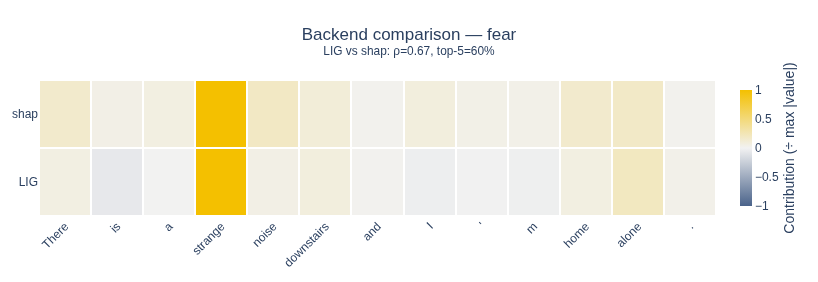

In [12]:
heatmap

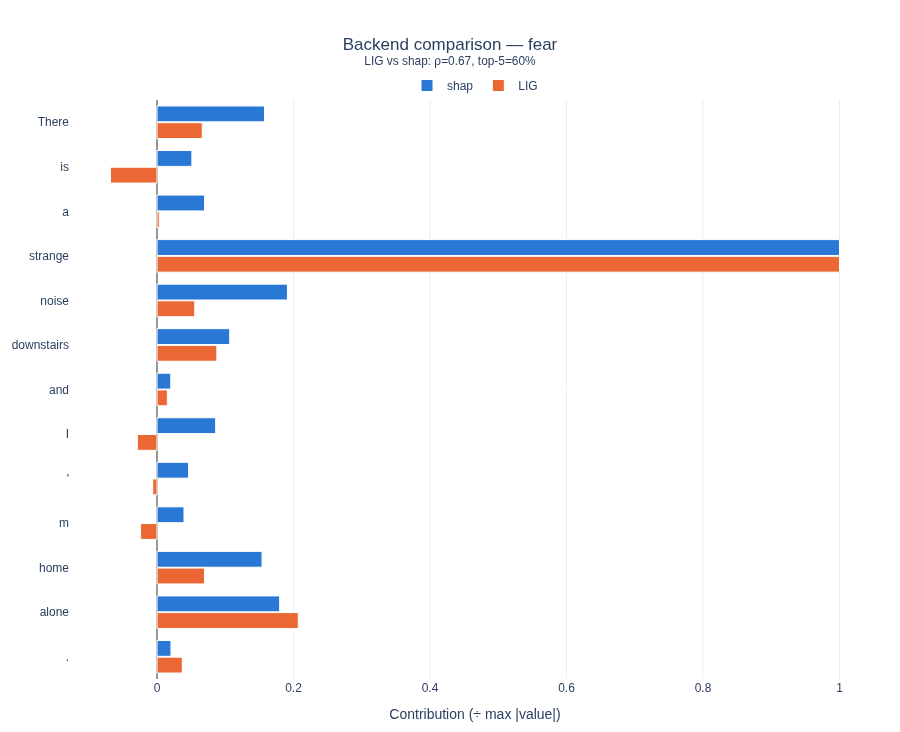

In [13]:
bars

In [14]:
highlight

Div([Div(children=[Span(children='■ ', style={'color': 'rgba(244, 192, 0, 1.0)'}), Span(children='positive  ', style={'fontSize': '0.78em', 'color': '#555'}), Span(children='■ ', style={'color': 'rgba(74, 99, 138, 0.7)'}), Span(children='negative  ', style={'fontSize': '0.78em', 'color': '#555'}), Span(children='struck-through', style={'fontSize': '0.78em', 'color': '#aaa', 'textDecoration': 'line-through'}), Span(children=' not attributed', style={'fontSize': '0.78em', 'color': '#555'})], style={'marginBottom': '4px'}), Div(children='LIG vs shap: ρ=0.67, top-5=60%', style={'fontSize': '0.78em', 'color': '#555', 'marginBottom': '6px'}), Div(children=[Div(children=[Div(children='shap', style={'fontSize': '0.8em', 'fontWeight': '600', 'color': '#444'}), Div(children=[Span(children='There ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(253,245,214)', 'color': '#111111'}, title='There: +0.1574'), Span(children='is ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(254,251,241)', 'color': '#111111'}, title='is: +0.0511'), Span(children='a ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(254,250,237)', 'color': '#111111'}, title='a: +0.0697'), Span(children='strange ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(244,192,0)', 'color': '#111111'}, title='strange: +1.0000'), Span(children='noise ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(252,242,206)', 'color': '#111111'}, title='noise: +0.1910'), Span(children='downstairs ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(253,248,227)', 'color': '#111111'}, title='downstairs: +0.1065'), Span(children='and ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(254,253,249)', 'color': '#111111'}, title='and: +0.0202'), Span(children='I ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(254,249,233)', 'color': '#111111'}, title='I: +0.0860'), Span(children="' ", style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(254,252,243)', 'color': '#111111'}, title="': +0.0461"), Span(children='m ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(254,252,244)', 'color': '#111111'}, title='m: +0.0395'), Span(children='home ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(253,245,215)', 'color': '#111111'}, title='home: +0.1539'), Span(children='alone ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(253,243,209)', 'color': '#111111'}, title='alone: +0.1797'), Span(children='. ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(254,253,249)', 'color': '#111111'}, title='.: +0.0205')], style={'lineHeight': '2.2', 'fontSize': '1.0em'})], style={'padding': '8px 12px', 'borderBottom': '1px solid #eeeeee'}), Div(children=[Div(children='LIG', style={'fontSize': '0.8em', 'fontWeight': '600', 'color': '#444'}), Div(children=[Span(children='There ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'display': 'inline-block', 'backgroundColor': 'rgb(254,250,238)', 'color': '#111111'}, title='There: +0.0663'), Span(children='is ', style={'padding': '3px 5px', 'borderRadius': '3px', 'margin': '2px 1px', 'displ

In [15]:
# Variations: a specific class instead of the predicted one, with raw values (meaningful here since
# both backends share the logit space); only the 8 strongest words.
idx = model.label_names.index("joy")

joy_raw = shap_exp.plot.compare(others, row=0, label_idx=idx, normalize=None)
top8 = shap_exp.plot.compare(others, row=1, max_tokens=8)

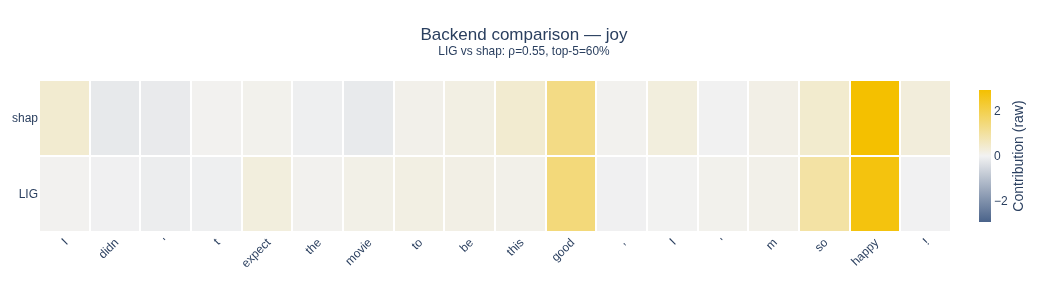

In [16]:
joy_raw

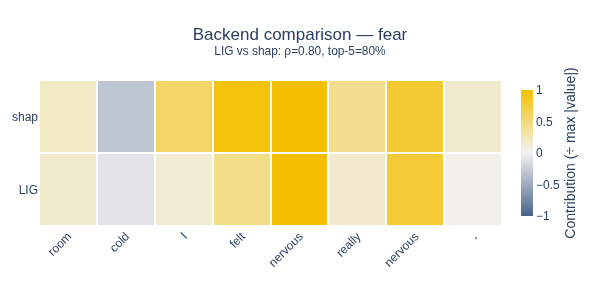

In [17]:
top8

### The corpus - one agreement score per text and backend pair

Before choosing a particular backend, we would rather like to investigate how they compare on a corpus than on a single sentence. Then we can compute useful metrics: Spearman correlation, Pearson correlation, cosine similarity, sign agreement ratio, overlapping top-k words ratio, or the strongest word's share of a backend's total attribution.

| Metric | Question it answers | Range | Note |
|---|---|---|---|
| `spearman` | Do both backends rank *every* word in the same order? | −1 to 1 | Every word counts the same, so when one word dominates, the order of the near-zero rest decides it. |
| `pearson` | Do the contribution values vary together, word by word? | −1 to 1 | Bigger words count more; measured around each backend's mean. |
| `cosine` | Do both backends put their attribution on the same words, with the same signs? | −1 to 1 | Like Pearson but measured around zero ("no effect"); the best single "same story?" score. |
| `sign_agreement` | On what share of words do they agree on the direction (pushes toward / away from the class)? | 0 to 1 | Small near-zero words can flip sign easily. |
| `top_k_overlap` | What share of the *k* most important words do they have in common? | 0 to 1 | Ignores signs and values beyond the top *k*. |
| `top_share_a` / `top_share_b` | How concentrated is each backend's attribution, i.e. the strongest word's share of the total? | 1/n to 1 | Not an agreement score: it says how far to trust `spearman`. High → prefer `cosine`. |

In [18]:
from shapash.explainer.nlp_comparison import corpus_agreement

scores = corpus_agreement(shap_exp, others, top_k=5)  # rows=[0, 1, 2, ...] to score only some texts
scores.round(2)

,row,text,label,backend_a,backend_b,spearman,pearson,cosine,sign_agreement,top_k_overlap,top_share_a,top_share_b
0,0,"I didn't expect the movie to be this good, I'm...",joy,shap,LIG,0.55,0.95,0.96,0.67,0.6,0.41,0.42
1,1,"The waiting room was cold and I felt nervous, ...",fear,shap,LIG,0.80,0.87,0.91,0.88,0.8,0.20,0.30
2,2,Why would you do that? I'm furious.,anger,shap,LIG,0.27,0.99,0.99,0.73,0.8,0.69,0.76
3,3,We finally got the keys to our new house today.,joy,shap,LIG,0.76,0.87,0.93,0.82,0.8,0.14,0.19
4,4,I miss my grandmother more than I can say.,sadness,shap,LIG,0.79,0.75,0.77,0.50,0.8,0.26,0.58
5,5,He forgot my birthday again and didn't even ap...,anger,shap,LIG,0.85,0.85,0.90,0.92,0.6,0.50,0.30
6,6,There is a strange noise downstairs and I'm ho...,fear,shap,LIG,0.67,0.98,0.97,0.69,0.6,0.47,0.60
7,7,She held my hand the whole evening and I never...,anger,shap,LIG,0.67,0.89,0.85,0.73,0.8,0.20,0.30
8,8,"Wow, I really did not see that ending coming!",joy,shap,LIG,0.55,0.80,0.86,0.73,0.6,0.30,0.51
9,9,"The train is late again, this is so annoying.",anger,shap,LIG,0.81,0.99,0.98,0.91,0.6,0.56,0.70


Some findings:
- Row 2 ("I'm furious"): Spearman rho is 0.27 but cosine is 0.99, because one word carries about 70% of the attribution and the low ρ is only about the near-zero rest. It's the best illustration of why one metric isn't enough.
- Row 4: the backends genuinely disagree. Cosine is 0.77, sign agreement is 0.50, and LIG concentrates on one word (top share 0.58) while SHAP spreads it out (0.26).

In [19]:
# In general: aggregate and compute the median over texts, per backend pair. 
# Read spearman with cosine and top_share: a low spearman with a high cosine and a high top_share means 
# both backends agree on the word that carries the prediction and only order the near-zero rest differently.

metrics = ["spearman", "pearson", "cosine", "sign_agreement", "top_k_overlap", "top_share_a", "top_share_b"]
scores.groupby(["backend_a", "backend_b"])[metrics].median().round(2)

,,spearman,pearson,cosine,sign_agreement,top_k_overlap,top_share_a,top_share_b
backend_a,backend_b,,,,,,,
shap,LIG,0.69,0.88,0.92,0.75,0.6,0.36,0.5


Conclusion: SHAP and LIG agree well overall (median cosine 0.92, ρ 0.69); they differ mostly on how they spread the small words.

In [20]:
# Where they disagree most: the texts worth opening with ``compare``.
worst = scores.nsmallest(3, "cosine")
worst[["row", "label", "spearman", "pearson", "cosine", "top_share_a", "text"]].round(2)

,row,label,spearman,pearson,cosine,top_share_a,text
4,4,sadness,0.79,0.75,0.77,0.26,I miss my grandmother more than I can say.
7,7,anger,0.67,0.89,0.85,0.20,She held my hand the whole evening and I never...
8,8,joy,0.55,0.80,0.86,0.30,"Wow, I really did not see that ending coming!"


In [21]:
# The same, as plots — one dot per text (hover for its row), the box gives median and quartiles
corpus_metric = shap_exp.plot.compare_corpus(others, metric="cosine")
corpus_topk = shap_exp.plot.compare_corpus(others, metric="top_k_overlap", top_k=5)

# Then drill down into the text they disagree on most.
worst_text = shap_exp.plot.compare(others, row=int(worst["row"].iloc[0]))


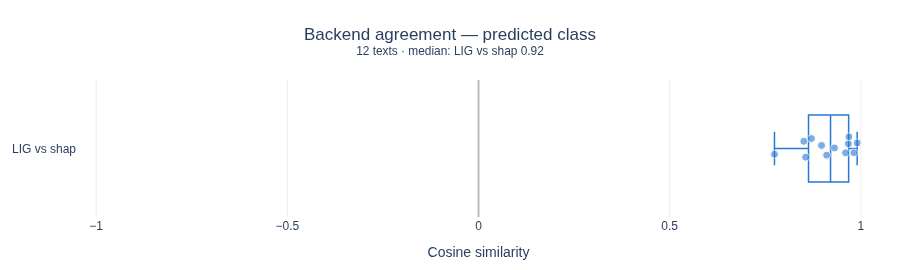

In [22]:
corpus_metric

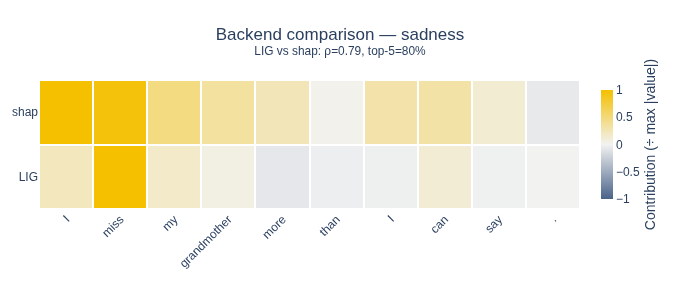

In [23]:
worst_text